<a href="https://colab.research.google.com/github/Simran-Dalvi/TensorFlow/blob/main/00_tensorflow_fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#tensorflow fundamentals
we are going to cover the most fundamentals of tensor using tensorflow

we are going to cover:
* intro to tensor
* getting info from tensor
* manipulating tensor
* tensor and numpy
* using @tf.functions
using gpu with tensorflow
* excersises to try your self


#Introduction to tensorflow

In [ ]:
#import tensorflow
import tensorflow as tf
print(tf.__version__)

2.19.0


In [ ]:
#create tensors with tf.constant()
scalar = tf.constant(7)
scalar

<tf.Tensor: shape=(), dtype=int32, numpy=7>

In [ ]:
# check the number of dimensions of a tensor
# (ndim stands for number of dimensions )
scalar.ndim

0

In [ ]:
# create a vector
vector = tf.constant([10,10])
vector

<tf.Tensor: shape=(2,), dtype=int32, numpy=array([10, 10], dtype=int32)>

In [ ]:
# check the dimensions of our vector
vector.ndim

1

In [ ]:
# create a matrix
matrix = tf.constant([[10, 7],
                      [7, 10]])
matrix

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[10,  7],
       [ 7, 10]], dtype=int32)>

In [ ]:
matrix.ndim

2

In [ ]:
#create another matrix
another_matrix = tf.constant([[10., 7., 5.],
                              [3., 2., 4.],
                              [8., 9., 6.]], dtype= tf.float16)
# specify the data type with dtype parameter
another_matrix

<tf.Tensor: shape=(3, 3), dtype=float16, numpy=
array([[10.,  7.,  5.],
       [ 3.,  2.,  4.],
       [ 8.,  9.,  6.]], dtype=float16)>

In [ ]:
#what is the dimension of our matrix
another_matrix.ndim

2

In [ ]:
#lets create a tensor
tensor = tf.constant([[[1, 2, 3],
                      [4, 5, 6]],
                     [[7, 8, 9],
                      [10, 11, 12]],
                     [[13, 14, 15],
                      [16, 17, 18]]])
tensor

<tf.Tensor: shape=(3, 2, 3), dtype=int32, numpy=
array([[[ 1,  2,  3],
        [ 4,  5,  6]],

       [[ 7,  8,  9],
        [10, 11, 12]],

       [[13, 14, 15],
        [16, 17, 18]]], dtype=int32)>

In [ ]:
tensor.ndim

3

what we've created so far:
* Scalar: a single number
* Vector: a number with direction (e.r. wind speed and direction)
* Matrix: a 2 dimensional array of number
* Tensor: an n-dimensional array of numbers (when n can be any number, a 0-dimensional tensor is a scalar, a 1-dimensional tensor is a vector)

### creating tensors with tf.Variables

In [ ]:
#create the same tensor with t.variable() as above
changeable_tensor = tf.Variable([10, 7])
unchangeable_tensor = tf.constant([10, 7])
changeable_tensor, unchangeable_tensor

(<tf.Variable 'Variable:0' shape=(2,) dtype=int32, numpy=array([10,  7], dtype=int32)>,
 <tf.Tensor: shape=(2,), dtype=int32, numpy=array([10,  7], dtype=int32)>)

In [ ]:
# lets try change one of the elements
changeable_tensor[0].assign(7)

<tf.Variable 'UnreadVariable' shape=(2,) dtype=int32, numpy=array([7, 7], dtype=int32)>

In [ ]:
# #now unchangeable tensor
# unchangeable_tensor[0].assign(7)
# unchangeable_tensor



> NOTE: Rarely in practice will you need to decide whether to use tf.constant or tf.Variable to create tensors, as TensorFlow does this for you. However, if in doubt, use tf.constant and change it later if needed



### Creating random tensors

Random tensors are tensors of some arbitary size which contains random numbers.

why we needed?

The neural networks initialize with random weights (only at beginning) and then update with more learning.

In [ ]:
# create two random but same tensors
random_1 = tf.random.Generator.from_seed(42) #set seed for reproducability
random_1 = random_1.normal(shape=(3, 2))
random_2 = tf.random.Generator.from_seed(123)
random_2 = random_2.normal(shape=(3,2))

# are the equal?
random_1, random_2, random_1 == random_2

(<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
 array([[-0.7565803 , -0.06854702],
        [ 0.07595026, -1.2573844 ],
        [-0.23193763, -1.8107855 ]], dtype=float32)>,
 <tf.Tensor: shape=(3, 2), dtype=float32, numpy=
 array([[ 0.8673864 , -0.29899067],
        [-0.9310337 , -1.5828488 ],
        [ 1.2481191 , -0.6770643 ]], dtype=float32)>,
 <tf.Tensor: shape=(3, 2), dtype=bool, numpy=
 array([[False, False],
        [False, False],
        [False, False]])>)

In [ ]:
# x = random_1.state # This line causes an error because tf.Tensor objects do not have a 'state' attribute.
# x
# 'tensorflow.python.framework.ops.EagerTensor' object has no attribute 'state' means that tf.Tensor objects do not have a property called state. In the previous cell, the random_1 variable was reassigned from a tf.random.Generator to a tf.Tensor when random_1.normal() was called. You are trying to access .state on this resulting tf.Tensor, which doesn't have such an attribute.

### Shuffle the order of elements in a tensor

Why do we need to shuffle?

The first 100 were images of ramen and last 50 were spaghetti while training a model.

so we need to mix them all

In [ ]:
not_shuffled = tf.constant([[10, 7],
                            [3, 4],
                            [2, 5]])
not_shuffled

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[10,  7],
       [ 3,  4],
       [ 2,  5]], dtype=int32)>

In [ ]:
# shuffle our non shuffled tensor

shuffled = tf.random.shuffle(not_shuffled, seed=42) # still getting diffrent values after setting seed
shuffled
# shuffled along its first dimension

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[ 2,  5],
       [ 3,  4],
       [10,  7]], dtype=int32)>

In [ ]:
# now try with set_seed

tf.random.set_seed(42)
tf.random.shuffle(not_shuffled) #now everytime this code is run with get the same shuffled tensor

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[ 3,  4],
       [ 2,  5],
       [10,  7]], dtype=int32)>

In [ ]:
# now try with different operation level seeds

tf.random.set_seed(42) #global seed
tf.random.shuffle(not_shuffled, seed=105) # operational seed

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[ 2,  5],
       [10,  7],
       [ 3,  4]], dtype=int32)>

If you want our shuffled tensors to be in the same order, we've got to use the global level random seed and the operational level random seed:

> If both the global and the operation seed are set: Both seeds are used in conjunction to determine the random sequence.

### Other ways to create tensors
numpy methode

The main reason between Numpy arrays and TensorFlow tensors is that tensors can be run on a GPU (much faste for numerical computing)

In [ ]:
tf.ones([10,7])

<tf.Tensor: shape=(10, 7), dtype=float32, numpy=
array([[1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1.]], dtype=float32)>

In [ ]:
tf.zeros(shape=(3, 4))

<tf.Tensor: shape=(3, 4), dtype=float32, numpy=
array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]], dtype=float32)>

In [ ]:
# you can also turn numpy array to tensoflow tensors
import numpy as np
#capital for matrix or tensor and non-capital for vectors

numpy_A = np.arange(1, 25, dtype=np.int32)
numpy_A

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24], dtype=int32)

In [ ]:
A = tf.constant(numpy_A)
B = tf.constant(numpy_A, shape=(2, 3, 4))
A, B
# the elements in A should be the same as elements in B. so deciding the shape is tricky
#  2 * 3 * 4 = 24

(<tf.Tensor: shape=(24,), dtype=int32, numpy=
 array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24], dtype=int32)>,
 <tf.Tensor: shape=(2, 3, 4), dtype=int32, numpy=
 array([[[ 1,  2,  3,  4],
         [ 5,  6,  7,  8],
         [ 9, 10, 11, 12]],
 
        [[13, 14, 15, 16],
         [17, 18, 19, 20],
         [21, 22, 23, 24]]], dtype=int32)>)

In [ ]:
# A = tf.constant(numpy_A)
# B = tf.constant(numpy_A, shape=(2, 3, 5))
# A, B
# Eager execution of tf.constant with unsupported shape.
# Tensor [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
#  (converted from [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24])
# has 24 elements, but got `shape` (2, 3, 5) with 30 elements)

### Getting more information from tensors


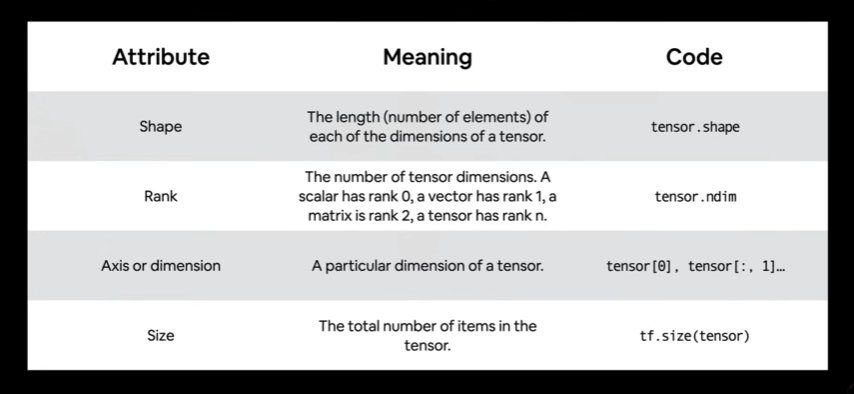

In [ ]:
# create a rank 4 tensor
rank_4 = tf.zeros(shape=([2, 3, 4, 5]))
rank_4

<tf.Tensor: shape=(2, 3, 4, 5), dtype=float32, numpy=
array([[[[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]]],


       [[[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]]]], dtype=float32)>

In [ ]:
rank_4[0]

<tf.Tensor: shape=(3, 4, 5), dtype=float32, numpy=
array([[[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]],

       [[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]],

       [[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]]], dtype=float32)>

In [ ]:
rank_4[1,0]

<tf.Tensor: shape=(4, 5), dtype=float32, numpy=
array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]], dtype=float32)>

In [ ]:
rank_4[1,2,0]

<tf.Tensor: shape=(5,), dtype=float32, numpy=array([0., 0., 0., 0., 0.], dtype=float32)>

In [ ]:
# rank_4[1,2,0,0].assign(5.2)
# wont work because tf. tensors are immutable
# convert it to tf.Variable

In [ ]:
rank_4.shape, rank_4.ndim, tf.size(rank_4) # 2*3*4*5

(TensorShape([2, 3, 4, 5]), 4, <tf.Tensor: shape=(), dtype=int32, numpy=120>)

In [ ]:
#Get various attribute of our tensor
print("Datatypes of every element:", rank_4.dtype)
print("Number of dimensions (rank):", rank_4.ndim)
print("Shape of tensor:", rank_4.shape)
print("Elements along the 0 axis", rank_4.shape[0])
print("Elements along the last axis:", rank_4.shape[-1])
print("Total number of elements in our tensor:", tf.size(rank_4).numpy())

Datatypes of every element: <dtype: 'float32'>
Number of dimensions (rank): 4
Shape of tensor: (2, 3, 4, 5)
Elements along the 0 axis 2
Elements along the last axis: 5
Total number of elements in our tensor: 120


### Indexing tensors

Tensors can be indexed just like Python list

In [ ]:
some_list  = [1, 2, 3, 4]
some_list[:2]

[1, 2]

In [ ]:
# get the first two elements of each dimension
rank_4[:2, :2, :2, :2]

<tf.Tensor: shape=(2, 2, 2, 2), dtype=float32, numpy=
array([[[[0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.]]],


       [[[0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.]]]], dtype=float32)>

In [ ]:
# get first element from each dimension from each index except for the final one

rank_4[:1, :1, :1]
#  same as rank_4[:1, :1, :1, :]

<tf.Tensor: shape=(1, 1, 1, 5), dtype=float32, numpy=array([[[[0., 0., 0., 0., 0.]]]], dtype=float32)>

In [ ]:
rank_4[:1, :1, :, :1]

<tf.Tensor: shape=(1, 1, 4, 1), dtype=float32, numpy=
array([[[[0.],
         [0.],
         [0.],
         [0.]]]], dtype=float32)>

In [ ]:
rank_4[:1, :, :1, :1]

<tf.Tensor: shape=(1, 3, 1, 1), dtype=float32, numpy=
array([[[[0.]],

        [[0.]],

        [[0.]]]], dtype=float32)>

In [ ]:
# create a rank 2 tensor
# rank_2 = tf.ones(shape=(3,4))
rank_2 = tf.constant([[10, 7],
                      [3, 4]])
rank_2, rank_2.shape, rank_2.ndim, rank_2.dtype, tf.size(rank_2)

(<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
 array([[10,  7],
        [ 3,  4]], dtype=int32)>,
 TensorShape([2, 2]),
 2,
 tf.int32,
 <tf.Tensor: shape=(), dtype=int32, numpy=4>)

In [ ]:
#get the last item of each row of our rank 2 tensor
rank_2[:, -1]

<tf.Tensor: shape=(2,), dtype=int32, numpy=array([7, 4], dtype=int32)>

In [ ]:
# add in extra dimension to our rank 2 tensor
rank_3 = rank_2[..., tf.newaxis]
rank_3

<tf.Tensor: shape=(2, 2, 1), dtype=int32, numpy=
array([[[10],
        [ 7]],

       [[ 3],
        [ 4]]], dtype=int32)>

In [ ]:
#alternative to tf.newaxis
tf.expand_dims(rank_2,axis=-1) # "-1" means expand the final axis

<tf.Tensor: shape=(2, 2, 1), dtype=int32, numpy=
array([[[10],
        [ 7]],

       [[ 3],
        [ 4]]], dtype=int32)>

In [ ]:
tf.expand_dims(rank_2, axis=0)

<tf.Tensor: shape=(1, 2, 2), dtype=int32, numpy=
array([[[10,  7],
        [ 3,  4]]], dtype=int32)>

### Manipulation a Tensor (tensor operations)
**Basic Operations**


```
+, -, *, /
```



In [ ]:
# you can add value to a tensor using the addition operator
tensor = tf.constant([[10, 7],
                      [3, 4]])
tensor + 10

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[20, 17],
       [13, 14]], dtype=int32)>

In [ ]:
#multiplication also works
tensor * 10

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[100,  70],
       [ 30,  40]], dtype=int32)>

In [ ]:
tensor - 10

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[ 0, -3],
       [-7, -6]], dtype=int32)>

In [ ]:
# we can use the tensorflow built in function too
tf.multiply(tensor, 100)

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[1000,  700],
       [ 300,  400]], dtype=int32)>

**Matrix Multiplication**

In matrix learning, matrix multiplication is one of the most common tensor operation

There are two ruules our tensor (0r matrices) need to fullfil if we are goig to matrix multiply them:

1. The inner dimensions must match.
2. th resulting matrix has the shape of the outer dimensions.

In [ ]:
#matrix multiplication in tensorflow

print(tensor)
tf.matmul(tensor, tensor)

tf.Tensor(
[[10  7]
 [ 3  4]], shape=(2, 2), dtype=int32)


<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[121,  98],
       [ 42,  37]], dtype=int32)>

In [ ]:
tensor * tensor

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[100,  49],
       [  9,  16]], dtype=int32)>

In [ ]:
#matrix multiplication with python operator "@"

tensor @ tensor

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[121,  98],
       [ 42,  37]], dtype=int32)>

In [ ]:
tensor.shape

TensorShape([2, 2])

In [ ]:
x = tf.constant([[[ 1,  2,  3],
                  [ 4,  5,  6]],
                 [[ 7,  8,  9],
                  [10, 11, 12]]]) # shape =(2, 2, 3)
tf.transpose(x) # perm = (2, 1, 0), shape=(3, 2, 2)

# OUTPUT: ([[[ 1,  7],
#         [ 4, 10]],

#        [[ 2,  8],
#         [ 5, 11]],

#        [[ 3,  9],
#         [ 6, 12]]],

tf.transpose(x, perm=[0, 2, 1]) # shape= (2, 3, 2)

<tf.Tensor: shape=(2, 3, 2), dtype=int32, numpy=
array([[[ 1,  4],
        [ 2,  5],
        [ 3,  6]],

       [[ 7, 10],
        [ 8, 11],
        [ 9, 12]]], dtype=int32)>

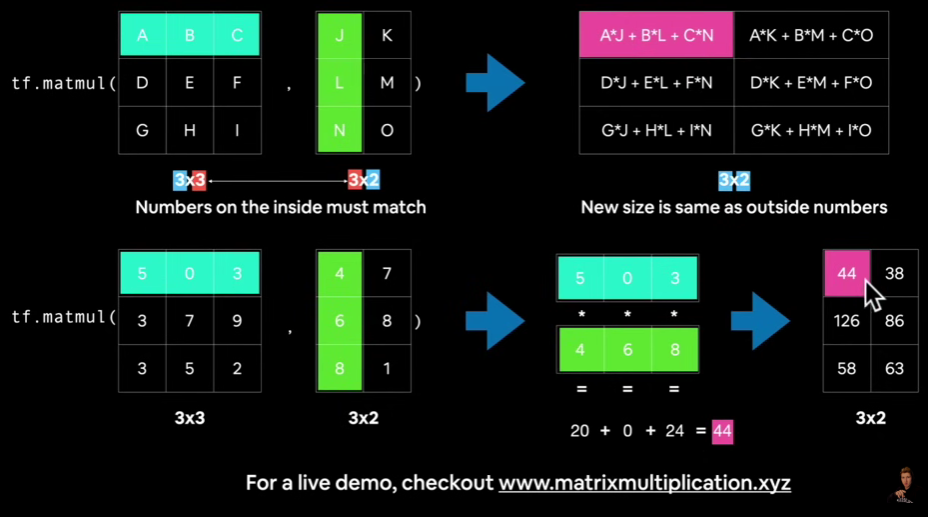

In [ ]:
#create a tensor (3, 2)
X = tf.constant([[1, 2],
                 [3, 4],
                 [5, 6]])
Y = tf.constant([[7, 8],
                 [9,10],
                 [11, 12]])

X, Y

(<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
 array([[1, 2],
        [3, 4],
        [5, 6]], dtype=int32)>,
 <tf.Tensor: shape=(3, 2), dtype=int32, numpy=
 array([[ 7,  8],
        [ 9, 10],
        [11, 12]], dtype=int32)>)

In [ ]:
#try to matrix multiply
# X @ Y.T
# If you are looking for numpy-related methods, please run the following:
# tf.experimental.numpy.experimental_enable_numpy_behavior()

In [ ]:
tf.reshape(Y, shape=(2, 3))

<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[ 7,  8,  9],
       [10, 11, 12]], dtype=int32)>

In [ ]:
# try to multiply X with reshaped Y
X @ tf.reshape(Y, shape= (2, 3))

<tf.Tensor: shape=(3, 3), dtype=int32, numpy=
array([[ 27,  30,  33],
       [ 61,  68,  75],
       [ 95, 106, 117]], dtype=int32)>

In [ ]:
tf.reshape(X, shape=(2, 3)).shape , Y.shape

(TensorShape([2, 3]), TensorShape([3, 2]))

In [ ]:
tf.matmul(tf.reshape(X, shape=(2, 3)), Y)

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[ 58,  64],
       [139, 154]], dtype=int32)>

In [ ]:
# wiil do the same with transpose
X, tf.transpose(X), tf.reshape(X, shape=(2, 3))

(<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
 array([[1, 2],
        [3, 4],
        [5, 6]], dtype=int32)>,
 <tf.Tensor: shape=(2, 3), dtype=int32, numpy=
 array([[1, 3, 5],
        [2, 4, 6]], dtype=int32)>,
 <tf.Tensor: shape=(2, 3), dtype=int32, numpy=
 array([[1, 2, 3],
        [4, 5, 6]], dtype=int32)>)

In [ ]:
# now multiply them with transpose
tf.transpose(X) @ Y

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[ 89,  98],
       [116, 128]], dtype=int32)>

**The dot product**
matrix multiplication is also referred to as the dot product.

You can perform matrix multiplication using:
* `tf.matmul()`
* `tf.tensordot()`
* `@`

In [ ]:
X, Y

(<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
 array([[1, 2],
        [3, 4],
        [5, 6]], dtype=int32)>,
 <tf.Tensor: shape=(3, 2), dtype=int32, numpy=
 array([[ 7,  8],
        [ 9, 10],
        [11, 12]], dtype=int32)>)

In [ ]:
# perform the dot product on X and Y (requires X or Y to be a transposed)

tf.tensordot(tf.transpose(X), Y, axes=1)

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[ 89,  98],
       [116, 128]], dtype=int32)>

In [ ]:
tf.tensordot(X, tf.transpose(Y), axes = 1)

<tf.Tensor: shape=(3, 3), dtype=int32, numpy=
array([[ 23,  29,  35],
       [ 53,  67,  81],
       [ 83, 105, 127]], dtype=int32)>

In [ ]:
# check the values of Y, reshape Y and transppose Y
print("Normal Y:")
print(Y, "\n")

print("Y reshaped to (2, 3):")
print(tf.reshape(Y, shape = (2, 3)), "\n")

print("Y transposed:")
print(tf.transpose(Y))

Normal Y:
tf.Tensor(
[[ 7  8]
 [ 9 10]
 [11 12]], shape=(3, 2), dtype=int32) 

Y reshaped to (2, 3):
tf.Tensor(
[[ 7  8  9]
 [10 11 12]], shape=(2, 3), dtype=int32) 

Y transposed:
tf.Tensor(
[[ 7  9 11]
 [ 8 10 12]], shape=(2, 3), dtype=int32)


Generally,  when performing matrix multiplication of two tensors and one of the axes dosen't line up, you will transpose (rather than reshape) one of the tensors to satisfy the matrix multiplication rules

### changing the data type of a tensor

In [ ]:
tf.__version__

'2.19.0'

In [ ]:
#create a new tensor with default datatype (float32)
B = tf.constant([1.7, 7.4])
B.dtype

tf.float32

In [ ]:
C = tf.constant([7, 10])
C.dtype

tf.int32

In [ ]:
# change from float32 to float16 (reduced precision)
# https://www.tensorflow.org/guide/mixed_precision

D = tf.cast(B, dtype=tf.float16)
D

<tf.Tensor: shape=(2,), dtype=float16, numpy=array([1.7, 7.4], dtype=float16)>

In [ ]:
# change from int32 to float 32
E = tf.cast(C, dtype=tf.float16)
E

<tf.Tensor: shape=(2,), dtype=float16, numpy=array([ 7., 10.], dtype=float16)>

### Aggregating tensors


The collecting of unit or parts into a mass of whole

Aggregating tensors = condensing them from multiple values down to a smaller amount of values.

In [ ]:
#get the absolute values
D = tf.constant([-7, -10])
D, tf.abs(D)

(<tf.Tensor: shape=(2,), dtype=int32, numpy=array([ -7, -10], dtype=int32)>,
 <tf.Tensor: shape=(2,), dtype=int32, numpy=array([ 7, 10], dtype=int32)>)

Lets go through the following forms of aggregation:

* Get the minimum
* maximum
* mean of tensor
* sum of a tensor

In [ ]:
# create a random tensor with values between 0 and 100 of size 50
E = tf.constant(np.random.randint(0, 100, size = 50))
E

<tf.Tensor: shape=(50,), dtype=int64, numpy=
array([64, 77, 60, 29, 24, 83, 11, 18, 97, 11, 55, 58, 80, 29, 56, 71, 99,
       61,  0, 73, 30, 44, 67, 36,  2,  6, 13, 18, 74, 82, 25, 88, 43, 98,
       83,  4, 23, 99, 57, 20, 79, 51, 95,  0, 33, 11, 68, 49,  0, 10])>

In [ ]:
tf.size(E), E.shape, E.ndim

(<tf.Tensor: shape=(), dtype=int32, numpy=50>, TensorShape([50]), 1)

In [ ]:
#Find the minimum
tf.reduce_min(E)

<tf.Tensor: shape=(), dtype=int64, numpy=0>

In [ ]:
# find the maximum
tf.reduce_max(E)

<tf.Tensor: shape=(), dtype=int64, numpy=99>

In [ ]:
#the mean
tf.reduce_mean(E)

<tf.Tensor: shape=(), dtype=int64, numpy=47>

In [ ]:
#the sum
tf.reduce_sum(E)

<tf.Tensor: shape=(), dtype=int64, numpy=2364>

In [ ]:
# the standard deviation
E = tf.cast(E, dtype=tf.float32)
tf.math.reduce_std(E)

<tf.Tensor: shape=(), dtype=float32, numpy=31.322860717773438>

In [ ]:
# the variance
tf.math.reduce_variance(E)

<tf.Tensor: shape=(), dtype=float32, numpy=981.12158203125>

### Find the positional maximum and minimum



In [ ]:
#  create a new tensor for finding the positional maximum and minimum
tf.random.set_seed(42)
F = tf.random.uniform(shape=[50])
F

<tf.Tensor: shape=(50,), dtype=float32, numpy=
array([0.6645621 , 0.44100678, 0.3528825 , 0.46448255, 0.03366041,
       0.68467236, 0.74011743, 0.8724445 , 0.22632635, 0.22319686,
       0.3103881 , 0.7223358 , 0.13318717, 0.5480639 , 0.5746088 ,
       0.8996835 , 0.00946367, 0.5212307 , 0.6345445 , 0.1993283 ,
       0.72942245, 0.54583454, 0.10756552, 0.6767061 , 0.6602763 ,
       0.33695042, 0.60141766, 0.21062577, 0.8527372 , 0.44062173,
       0.9485276 , 0.23752594, 0.81179297, 0.5263394 , 0.494308  ,
       0.21612847, 0.8457197 , 0.8718841 , 0.3083862 , 0.6868038 ,
       0.23764038, 0.7817228 , 0.9671384 , 0.06870162, 0.79873943,
       0.66028714, 0.5871513 , 0.16461694, 0.7381023 , 0.32054043],
      dtype=float32)>

In [ ]:
# find the positional maximum
tf.argmax(F)

<tf.Tensor: shape=(), dtype=int64, numpy=42>

In [ ]:
# Index on our largest value position
# F[tf.argmax(F)]

F[42]

<tf.Tensor: shape=(), dtype=float32, numpy=0.967138409614563>

In [ ]:
# Find the max value of F
tf.reduce_max(F)

<tf.Tensor: shape=(), dtype=float32, numpy=0.967138409614563>

In [ ]:
# check equality
tf.reduce_max(F) == F[tf.argmax(F)]

<tf.Tensor: shape=(), dtype=bool, numpy=True>

In [ ]:
# find the positional minimum
tf.argmin(F), F[tf.argmin(F)], tf.reduce_min(F)

(<tf.Tensor: shape=(), dtype=int64, numpy=16>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.009463667869567871>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.009463667869567871>)

### squeezing a tensor (removiang all dimensions)

In [ ]:
#crate a tensor to get started
G = tf.constant(tf.random.uniform(shape=[50]), shape=(1, 1, 1, 1, 50))
G

<tf.Tensor: shape=(1, 1, 1, 1, 50), dtype=float32, numpy=
array([[[[[0.68789124, 0.48447883, 0.9309944 , 0.252187  , 0.73115396,
           0.89256823, 0.94674826, 0.7493341 , 0.34925628, 0.54718256,
           0.26160395, 0.69734323, 0.11962581, 0.53484344, 0.7148968 ,
           0.87501776, 0.33967495, 0.17377627, 0.4418521 , 0.9008261 ,
           0.13803864, 0.12217975, 0.5754491 , 0.9417181 , 0.9186585 ,
           0.59708476, 0.6109482 , 0.82086265, 0.83269787, 0.8915849 ,
           0.01377225, 0.49807465, 0.57503664, 0.6856195 , 0.75972784,
           0.908944  , 0.40900218, 0.8765154 , 0.53890026, 0.42733097,
           0.401173  , 0.66623247, 0.16348064, 0.18220246, 0.97040176,
           0.06139731, 0.53034747, 0.9869994 , 0.4746945 , 0.8646754 ]]]]],
      dtype=float32)>

In [ ]:
G_sqezed= tf.squeeze(G)

In [ ]:
G_sqezed.shape

TensorShape([50])

### One-hot encoding

One Hot Encoding is a method for converting categorical variables into a binary format. It creates new columns for each category where 1 means the category is present and 0 means it is not. The primary purpose of One Hot Encoding is to ensure that categorical data can be effectively used in machine learning models.

In [ ]:
# create list of indices
some_list = [0, 1, 2, 3] # could be red, green, blue, purple

#one-hot encode list of indices
tf.one_hot(some_list, depth=6)

<tf.Tensor: shape=(4, 6), dtype=float32, numpy=
array([[1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0.]], dtype=float32)>

In [ ]:
# specify custom values for one hot encoding
tf.one_hot(some_list, depth=4, on_value="smoething is here", off_value = "NaN")

<tf.Tensor: shape=(4, 4), dtype=string, numpy=
array([[b'smoething is here', b'NaN', b'NaN', b'NaN'],
       [b'NaN', b'smoething is here', b'NaN', b'NaN'],
       [b'NaN', b'NaN', b'smoething is here', b'NaN'],
       [b'NaN', b'NaN', b'NaN', b'smoething is here']], dtype=object)>

### Squaring, log, square root

In [ ]:
# create a range
H = tf.range(1, 10)
H

<tf.Tensor: shape=(9,), dtype=int32, numpy=array([1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32)>

In [ ]:
# Square it
tf.square(H)

<tf.Tensor: shape=(9,), dtype=int32, numpy=array([ 1,  4,  9, 16, 25, 36, 49, 64, 81], dtype=int32)>

In [ ]:
# square root
tf.sqrt(tf.cast(H, dtype= tf.float32))

<tf.Tensor: shape=(9,), dtype=float32, numpy=
array([1.       , 1.4142135, 1.7320508, 2.       , 2.236068 , 2.4494898,
       2.6457512, 2.828427 , 3.       ], dtype=float32)>

In [ ]:
# log of each
tf.math.log(tf.cast(H, dtype = tf.float32))

<tf.Tensor: shape=(9,), dtype=float32, numpy=
array([0.       , 0.6931472, 1.0986123, 1.3862944, 1.609438 , 1.7917595,
       1.9459102, 2.0794415, 2.1972246], dtype=float32)>

### Tensor and NumPy

TensorFlow interacts beautifully with NumPy arrays

In [ ]:
# create a tensor directly from numpy array

J = tf.constant(np.array([3., 7., 10.]))
J

<tf.Tensor: shape=(3,), dtype=float64, numpy=array([ 3.,  7., 10.])>

In [ ]:
np.array(J), type(np.array(J))

(array([ 3.,  7., 10.]), numpy.ndarray)

In [ ]:
# Convert tensor J to numpy array
J, J.numpy(), type(J), type(J.numpy())

(<tf.Tensor: shape=(3,), dtype=float64, numpy=array([ 3.,  7., 10.])>,
 array([ 3.,  7., 10.]),
 tensorflow.python.framework.ops.EagerTensor,
 numpy.ndarray)

In [ ]:
# The default types of each are slightly different

numpy_J = tf.constant(np.array([3., 7., 10.]))
tensor_J = tf.constant([3., 7., 10.])

#check the datatypes of each
numpy_J.dtype, tensor_J.dtype

(tf.float64, tf.float32)